# A Framework for Modeling Traffic Behavior via User Equilibrium
# and Guiding System Efficiency Using Information Tolls

**Honors Thesis


---

## What This Notebook Demonstrates

This notebook implements the full thesis logic chain:

1. **Cell 1** — Setup: all imports, data, and functions
2. **Cell 2** — BPR function: how congestion grows
3. **Cell 3** — OD demand matrix
4. **Cell 4** — User Equilibrium (UE): selfish routing baseline
5. **Cell 5** — System Optimal (SO): what coordinated routing would achieve
6. **Cell 6** — Price of Anarchy: quantifying the inefficiency
7. **Cell 7** — Information Toll Framework: perceived cost model
8. **Cell 8** — Theta sweep: finding the sweet-spot toll magnitude
9. **Cell 9** — Sensitivity analysis: demand levels
10. **Cell 10** — Full results and thesis figures

**Required files** (same folder): `SiouxFalls_net.tntp`, `SiouxFalls_trips.tntp`,
`SiouxFalls_node.csv`, `SiouxFalls_flow.tntp`

## Cell 1 — Setup: All Imports, Data, and Functions
**Run this first.** Defines everything used in every subsequent cell.

In [2]:
# =================================================================
# CELL 1 -- SETUP: IMPORTS, DATA LOADING, ALL FUNCTIONS
# =================================================================

import pandas as pd
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

N_ZONES = 24

# -- Parse network (76 links) --
links = []
with open('SiouxFalls_net.tntp') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith(('<','~',';')): continue
        parts = line.replace(';','').split()
        if len(parts) >= 7:
            try:
                links.append({'A':int(parts[0]),'B':int(parts[1]),
                              'capacity':float(parts[2]),'length':float(parts[3]),
                              't0':float(parts[4]),'alpha':float(parts[5]),'beta':float(parts[6])})
            except ValueError: pass
net = pd.DataFrame(links).reset_index(drop=True)
print(f'[1a] Network: {len(net)} links')

# -- Parse OD demand --
demand = {}; current_origin = None
with open('SiouxFalls_trips.tntp') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith(('<',';')): continue
        if line.lower().startswith('origin'):
            current_origin = int(line.split()[1]); continue
        if current_origin is not None and ':' in line:
            pairs = line.replace(';','').split(); i = 0
            while i < len(pairs)-2:
                try:
                    d=int(pairs[i]); v=float(pairs[i+2])
                    if v>0: demand[(current_origin,d)]=v
                    i+=3
                except (ValueError,IndexError): i+=1
total_demand = sum(demand.values())
print(f'[1b] Demand:  {len(demand)} OD pairs  |  {total_demand:,.0f} vehicles')

# -- Parse node coordinates --
nodes_df = pd.read_csv('SiouxFalls_node.csv')
pos = {int(r['Node']):(r['X'],r['Y']) for _,r in nodes_df.iterrows()}
print(f'[1c] Nodes:   {len(nodes_df)} nodes')

# -- Parse best-known flows --
bk_rows = []
with open('SiouxFalls_flow.tntp') as f:
    for line in f:
        line=line.strip()
        if not line or line[0].isalpha(): continue
        parts=line.split()
        if len(parts)>=4:
            try: bk_rows.append({'A':int(parts[0]),'B':int(parts[1]),
                                  'bk_volume':float(parts[2]),'bk_cost':float(parts[3])})
            except (ValueError,IndexError): pass
best_known = pd.DataFrame(bk_rows)
print(f'[1d] Best-known: {len(best_known)} links')

# =================================================================
# BPR FUNCTIONS
# =================================================================

def bpr(t0, x, c, alpha=0.15, beta=4.0):
    '''BPR average cost: ta(xa) = t0*[1 + alpha*(x/c)^beta]'''
    return t0 * (1.0 + alpha * (x/c)**beta)

def bpr_marginal(t0, x, c, alpha=0.15, beta=4.0):
    '''Marginal cost: d/dx[x*t(x)] = t0*[1+alpha*(1+beta)*(x/c)^beta]
    Used for System Optimal routing.'''
    return t0 * (1.0 + alpha*(1.0+beta)*(x/c)**beta)

# =================================================================
# GRAPH AND ROUTING
# =================================================================

link_idx = {(int(r['A']),int(r['B'])):i for i,r in net.iterrows()}
graph = {}
for i,r in net.iterrows(): graph.setdefault(int(r['A']),{})[int(r['B'])]=i

def dijkstra(src, weights):
    dist = {n:float('inf') for n in range(1,N_ZONES+1)}
    dist[src]=0.0; prev={n:None for n in range(1,N_ZONES+1)}; pq=[(0.0,src)]
    while pq:
        d,u=heapq.heappop(pq)
        if d>dist[u]: continue
        for v,li in graph.get(u,{}).items():
            nd=d+weights[li]
            if nd<dist[v]: dist[v]=nd; prev[v]=u; heapq.heappush(pq,(nd,v))
    return dist,prev

def all_or_nothing(weights):
    '''Routes all demand on shortest paths given link weights.'''
    flows=np.zeros(len(net))
    for (orig,dest),vol in demand.items():
        if vol<=0: continue
        _,prev=dijkstra(orig,weights)
        node=dest
        while prev[node] is not None:
            up=prev[node]; li=link_idx.get((up,node))
            if li is not None: flows[li]+=vol
            node=up
    return flows

def frank_wolfe(cost_fn, toll=None, max_iter=200, tol=1e-3, label='', verbose=False):
    '''Frank-Wolfe assignment.
    cost_fn: bpr for UE, bpr_marginal for SO.
    toll:    information toll array [minutes] added to perceived cost.
    Returns: (flow_array, gap_list)'''
    t0a=net['t0'].values; ca=net['capacity'].values
    aa=net['alpha'].values; ba=net['beta'].values
    if toll is None: toll=np.zeros(len(net))
    x=all_or_nothing(t0a+toll); gaps=[]
    for it in range(1,max_iter+1):
        t_perceived=cost_fn(t0a,x,ca,aa,ba)+toll
        y=all_or_nothing(t_perceived)
        lo,hi=0.0,1.0
        for _ in range(32):
            lm=(lo+hi)/2.0; xl=x+lm*(y-x)
            tl=cost_fn(t0a,xl,ca,aa,ba)+toll
            if np.sum(tl*(y-x))<0: lo=lm
            else: hi=lm
        x=x+(lo+hi)/2*(y-x)
        t_act=bpr(t0a,x,ca,aa,ba); y2=all_or_nothing(t_act)
        n2=float(np.sum(t_act*(x-y2))); d2=float(np.sum(t_act*x))
        rgap=n2/d2 if d2>0 else float('inf'); gaps.append(max(rgap,1e-12))
        if verbose and it%50==0: print(f'  [{label}] iter {it}  rgap={rgap:.3e}')
        if rgap<tol:
            if verbose: print(f'  [{label}] converged iter {it}  rgap={rgap:.3e}')
            break
    return x,gaps

print()
print('All functions ready. Run cells below in order.')


[1a] Network: 76 links
[1b] Demand:  528 OD pairs  |  360,600 vehicles
[1c] Nodes:   24 nodes
[1d] Best-known: 76 links

All functions ready. Run cells below in order.


## Cell 2 — BPR Link Performance Function

$$t_a(x_a) = t_a^0\left[1 + \alpha\left(\frac{x_a}{c_a}\right)^\beta\right]$$

This models how travel time increases as more vehicles use a road.
All Sioux Falls links: **alpha=0.15, beta=4.0**

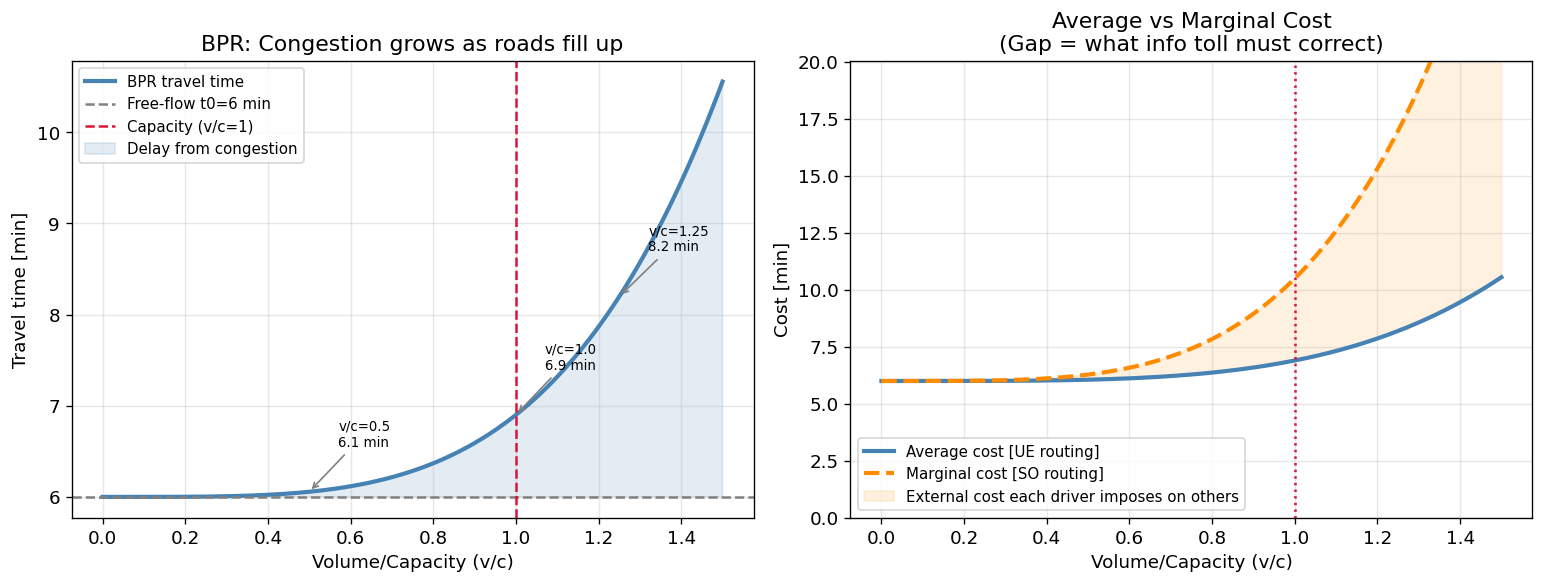

At v/c=1.0: t = 6.9 min (+15% over free-flow)
At v/c=1.5: t = 10.556 min (severe congestion)


In [3]:
# CELL 2 -- BPR VISUALIZATION (Requires Cell 1)

t0_ex  = 6.0
cap_ex = 25900.0

vcr_ax   = np.linspace(0, 1.5, 400)
x_plot   = vcr_ax * cap_ex
avg_cost = bpr(t0_ex, x_plot, cap_ex)
mar_cost = bpr_marginal(t0_ex, x_plot, cap_ex)
t0_arr   = np.full(400, t0_ex)   # array of constant t0, shape (400,)
zeros    = np.zeros(400)          # array of zeros, shape (400,)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: BPR travel time ----
ax1.plot(vcr_ax, avg_cost, color='steelblue', lw=2.5, label='BPR travel time')
ax1.axhline(t0_ex, color='gray', ls='--', lw=1.5, label='Free-flow t0=6 min')
ax1.axvline(1.0,   color='crimson', ls='--', lw=1.5, label='Capacity (v/c=1)')

# Shaded delay region using polygon (avoids fill_between scalar issue entirely)
shade_x = np.concatenate([vcr_ax, vcr_ax[::-1]])
shade_y = np.concatenate([avg_cost, t0_arr[::-1]])
ax1.fill(shade_x, shade_y, color='steelblue', alpha=0.15, label='Delay from congestion')

for vc_pt in [0.5, 1.0, 1.25]:
    t_pt = bpr(t0_ex, vc_pt * cap_ex, cap_ex)
    ax1.annotate(f'v/c={vc_pt}\n{t_pt:.1f} min',
                 xy=(vc_pt, t_pt), xytext=(vc_pt + 0.07, t_pt + 0.5),
                 fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

ax1.set_xlabel('Volume/Capacity (v/c)')
ax1.set_ylabel('Travel time [min]')
ax1.set_title('BPR: Congestion grows as roads fill up')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ---- Right: average vs marginal cost ----
ax2.plot(vcr_ax, avg_cost, color='steelblue',   lw=2.5, label='Average cost [UE routing]')
ax2.plot(vcr_ax, mar_cost, color='darkorange',  lw=2.5, ls='--', label='Marginal cost [SO routing]')
ax2.axvline(1.0, color='crimson', ls=':', lw=1.5)

# Shaded externality region using polygon
shade2_x = np.concatenate([vcr_ax, vcr_ax[::-1]])
shade2_y = np.concatenate([mar_cost, avg_cost[::-1]])
ax2.fill(shade2_x, shade2_y, color='darkorange', alpha=0.12,
         label='External cost each driver imposes on others')

ax2.set_xlabel('Volume/Capacity (v/c)')
ax2.set_ylabel('Cost [min]')
ax2.set_title('Average vs Marginal Cost\n(Gap = what info toll must correct)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, bpr(t0_ex, 1.5 * cap_ex, cap_ex) * 1.9)

plt.tight_layout()
plt.savefig('bpr_functions.png', dpi=150, bbox_inches='tight')
plt.show()

print('At v/c=1.0: t =', round(bpr(t0_ex, cap_ex, cap_ex), 3), 'min (+15% over free-flow)')
print('At v/c=1.5: t =', round(bpr(t0_ex, 1.5*cap_ex, cap_ex), 3), 'min (severe congestion)')


## Cell 3 — OD Demand Matrix
Shows how many drivers travel between each pair of zones.

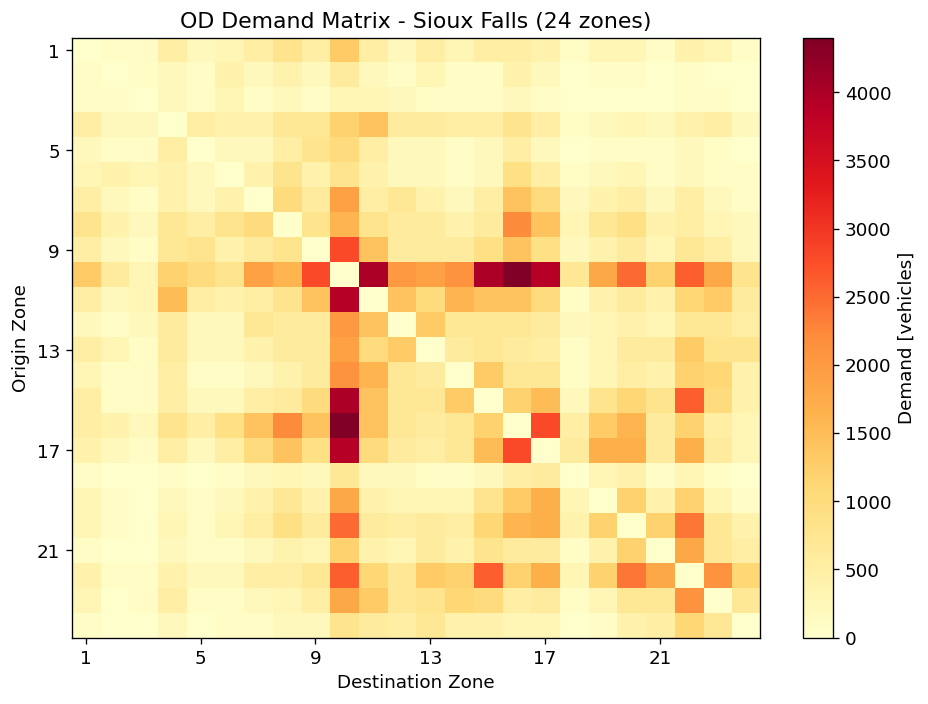

Total demand: 360,600 vehicles across 528 OD pairs


In [4]:
# CELL 3 -- OD DEMAND MATRIX (Requires Cell 1)

od_matrix=np.zeros((N_ZONES,N_ZONES))
for (orig,dest),vol in demand.items(): od_matrix[orig-1,dest-1]=vol

fig,ax=plt.subplots(figsize=(8,6))
im=ax.imshow(od_matrix,cmap='YlOrRd',aspect='auto')
plt.colorbar(im,ax=ax,label='Demand [vehicles]')
ax.set_xlabel('Destination Zone'); ax.set_ylabel('Origin Zone')
ax.set_title('OD Demand Matrix - Sioux Falls (24 zones)')
ticks=list(range(0,N_ZONES,4))
ax.set_xticks(ticks); ax.set_xticklabels([t+1 for t in ticks])
ax.set_yticks(ticks); ax.set_yticklabels([t+1 for t in ticks])
plt.tight_layout(); plt.savefig('od_matrix.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Total demand: {total_demand:,.0f} vehicles across {len(demand)} OD pairs')


## Cell 4 — User Equilibrium (Selfish Routing Baseline)

**Wardrop's First Principle:** No driver can reduce their own travel time by switching routes.

This is the *baseline* — what happens when every driver uses navigation to minimize
their own trip, with no coordination.

$$T_{UE} = \sum_{a \in A} x_a \cdot t_a(x_a)$$

In [5]:
# CELL 4 -- USER EQUILIBRIUM (Requires Cell 1)

print('Running User Equilibrium...')
x_ue, gaps_ue = frank_wolfe(bpr, label='UE', verbose=True)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values
t_ue   = bpr(t0a, x_ue, ca, aa, ba)
vcr_ue = x_ue / ca
T_UE   = float(np.sum(x_ue * t_ue))

print(f'\nUser Equilibrium Results:')
print(f'  T_UE = {T_UE:>14,.2f} veh.min (total system travel time)')
print(f'  Avg trip time    = {T_UE/total_demand:.2f} min/driver')
print(f'  Max v/c ratio    = {vcr_ue.max():.3f}')
print(f'  Links over capacity (v/c>1): {(vcr_ue>1).sum()}')


Running User Equilibrium...
  [UE] iter 50  rgap=3.448e-03
  [UE] iter 100  rgap=1.292e-03
  [UE] converged iter 130  rgap=9.665e-04

User Equilibrium Results:
  T_UE =   7,475,848.54 veh.min (total system travel time)
  Avg trip time    = 20.73 min/driver
  Max v/c ratio    = 2.554
  Links over capacity (v/c>1): 60


In [6]:
import numpy as np
val = net[['A','B']].copy()
val['flow_UE'] = x_ue
val = val.merge(best_known, on=['A','B'])
r_val = float(np.corrcoef(val['flow_UE'], val['bk_volume'])[0,1])
print(f'Pearson r = {r_val:.6f}')

Pearson r = 0.999938


## Cell 5 — System Optimal (Efficiency Benchmark)

**Wardrop's Second Principle:** Traffic is distributed to minimize TOTAL travel time.

This requires centralized control — no individual driver would voluntarily take
these routes. It is the benchmark we try to approach with information tolls.

$$T_{SO} = \min_{x} \sum_{a \in A} x_a \cdot t_a(x_a)$$

In [5]:
# CELL 5 -- SYSTEM OPTIMAL (Requires Cell 1)

print('Running System Optimal (marginal cost routing)...')
x_so, gaps_so = frank_wolfe(bpr_marginal, label='SO', verbose=True)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values
t_so   = bpr(t0a, x_so, ca, aa, ba)
vcr_so = x_so / ca
T_SO   = float(np.sum(x_so * t_so))

print(f'\nSystem Optimal Results:')
print(f'  T_SO = {T_SO:>14,.2f} veh.min (total system travel time)')
print(f'  Avg trip time    = {T_SO/total_demand:.2f} min/driver')
print(f'  Max v/c ratio    = {vcr_so.max():.3f}')
print(f'  Links over capacity (v/c>1): {(vcr_so>1).sum()}')


Running System Optimal (marginal cost routing)...
  [SO] iter 50  rgap=3.473e-02
  [SO] iter 100  rgap=2.934e-02
  [SO] iter 150  rgap=2.844e-02
  [SO] iter 200  rgap=2.826e-02

System Optimal Results:
  T_SO =   7,210,657.42 veh.min (total system travel time)
  Avg trip time    = 20.00 min/driver
  Max v/c ratio    = 2.571
  Links over capacity (v/c>1): 62


## Cell 6 — Price of Anarchy: The Inefficiency Gap

$$\text{PoA} = \frac{T_{UE}}{T_{SO}} \geq 1$$

This is the gap that information tolls try to close. A PoA of 1.04 means
selfish routing wastes 4% of total travel time — the system performs 4% worse
than it theoretically could with coordinated routing.

  UE vs SO COMPARISON
  T_UE  =   7,475,848.54  veh.min
  T_SO  =   7,210,657.42  veh.min
  Gap   =     265,191.12  veh.min  (0.74 min/driver)
  PoA   = 1.036778
  Inefficiency = 3.68%

Interpretation:
  Selfish routing (UE) wastes 265,191 vehicle-minutes
  vs coordinated routing (SO).
  This is equivalent to 0.74 extra minutes per driver.
  The information toll framework aims to recover this loss.


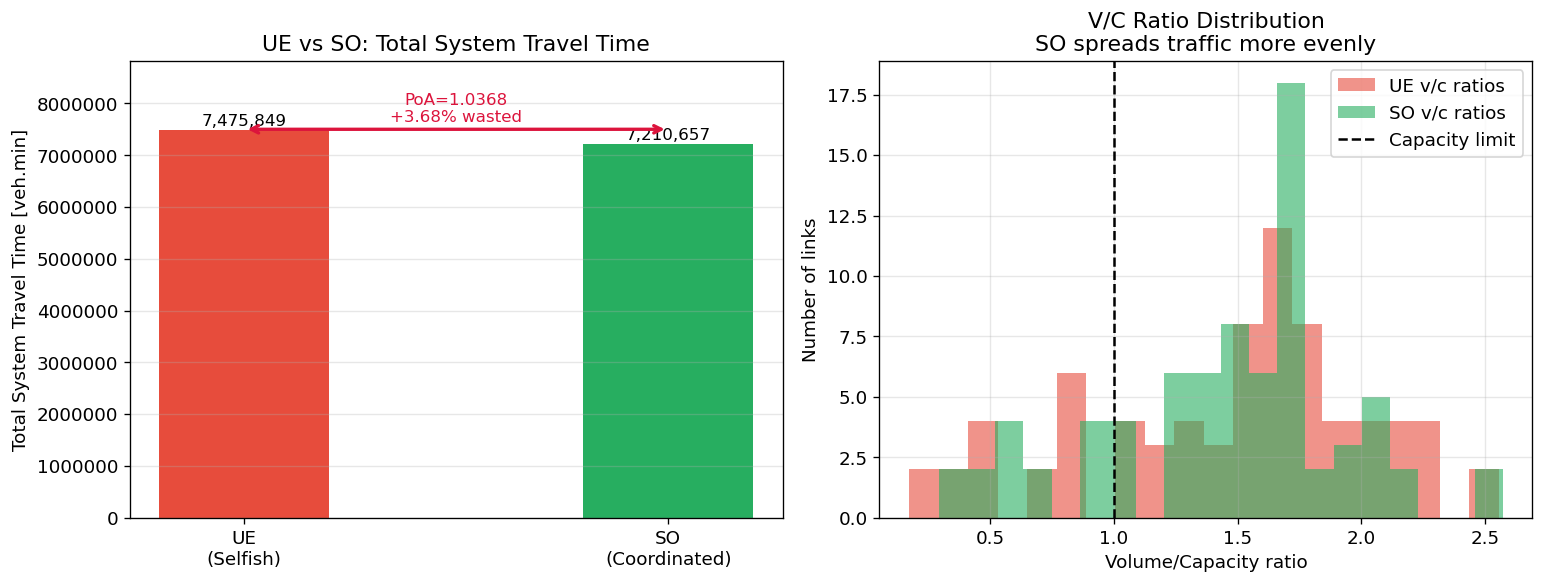

In [6]:
# CELL 6 -- PRICE OF ANARCHY (Requires Cells 1, 4, 5)

t0a=net['t0'].values; ca=net['capacity'].values
PoA = T_UE / T_SO
gap = T_UE - T_SO

print('='*60)
print('  UE vs SO COMPARISON')
print('='*60)
print(f'  T_UE  = {T_UE:>14,.2f}  veh.min')
print(f'  T_SO  = {T_SO:>14,.2f}  veh.min')
print(f'  Gap   = {gap:>14,.2f}  veh.min  ({gap/total_demand:.2f} min/driver)')
print(f'  PoA   = {PoA:.6f}')
print(f'  Inefficiency = {(PoA-1)*100:.2f}%')
print('='*60)
print()
print('Interpretation:')
print(f'  Selfish routing (UE) wastes {gap:,.0f} vehicle-minutes')
print(f'  vs coordinated routing (SO).')
print(f'  This is equivalent to {gap/total_demand:.2f} extra minutes per driver.')
print(f'  The information toll framework aims to recover this loss.')

# Side-by-side comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: TSTT bar chart
bars = ax1.bar(['UE\n(Selfish)','SO\n(Coordinated)'],
               [T_UE, T_SO], color=['#E74C3C','#27AE60'], width=0.4)
for bar, val_t in zip(bars, [T_UE, T_SO]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.005,
             f'{val_t:,.0f}', ha='center', va='bottom', fontsize=10)
ax1.annotate('', xy=(1,T_SO*1.04), xytext=(0,T_SO*1.04),
             arrowprops=dict(arrowstyle='<->',color='crimson',lw=2))
ax1.text(0.5, T_SO*1.06, f'PoA={PoA:.4f}\n+{(PoA-1)*100:.2f}% wasted',
         ha='center',color='crimson',fontsize=10)
ax1.set_ylabel('Total System Travel Time [veh.min]')
ax1.set_title('UE vs SO: Total System Travel Time')
ax1.set_ylim(0, T_UE*1.18); ax1.yaxis.get_major_formatter().set_scientific(False)
ax1.grid(axis='y',alpha=0.3)

# Right: v/c ratio distributions
ax2.hist(x_ue/ca, bins=20, alpha=0.6, color='#E74C3C', label='UE v/c ratios')
ax2.hist(x_so/ca, bins=20, alpha=0.6, color='#27AE60', label='SO v/c ratios')
ax2.axvline(1.0, color='black', ls='--', lw=1.5, label='Capacity limit')
ax2.set_xlabel('Volume/Capacity ratio'); ax2.set_ylabel('Number of links')
ax2.set_title('V/C Ratio Distribution\nSO spreads traffic more evenly')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('ue_vs_so.png',dpi=150,bbox_inches='tight'); plt.show()


## Cell 7 — Information Toll Framework

### Core Concept

An **information toll** is NOT a monetary charge. It is a routing signal —
a slight upward adjustment to the perceived travel time shown to drivers
by their navigation app.

$$\text{Perceived cost}_a = t_a(x_a) + \tau_a^{\text{info}}$$

Drivers now minimize **perceived cost** instead of actual travel time.
By carefully choosing the toll $\tau_a$, we can shift equilibrium toward SO.

### First-Best (Pigouvian) Information Toll

The theoretically optimal toll that exactly closes the UE-SO gap:

$$\tau_a^* = x_a \cdot t_a'(x_a) = x_a \cdot t_a^0 \cdot \frac{\alpha\beta}{c_a}\left(\frac{x_a}{c_a}\right)^{\beta-1}$$

### Parameterized Toll (Bounded Rationality)

Full Pigouvian tolls may distort routing too much — drivers would lose trust.
We parameterize by $\theta \in [0,1]$:

$$\tau_a(\theta) = \theta \cdot \tau_a^*$$

- $\theta = 0$: no toll, pure UE
- $\theta = 1$: full Pigouvian toll
- **Thesis question:** What is the optimal $\theta$?

First-Best (Pigouvian) Information Toll Statistics:
  Mean toll:    18.70 min  =  $6.23/vehicle
  Median toll:  19.50 min  =  $6.50/vehicle
  Max toll:     64.86 min  =  $21.62/vehicle
  Zero toll links: 0 (uncongested roads need no signal)

The full Pigouvian toll (theta=1.0) actually HURTS efficiency
because it over-distorts routing (shown in Cell 8).
The thesis finds a sweet-spot theta that captures most of the benefit.


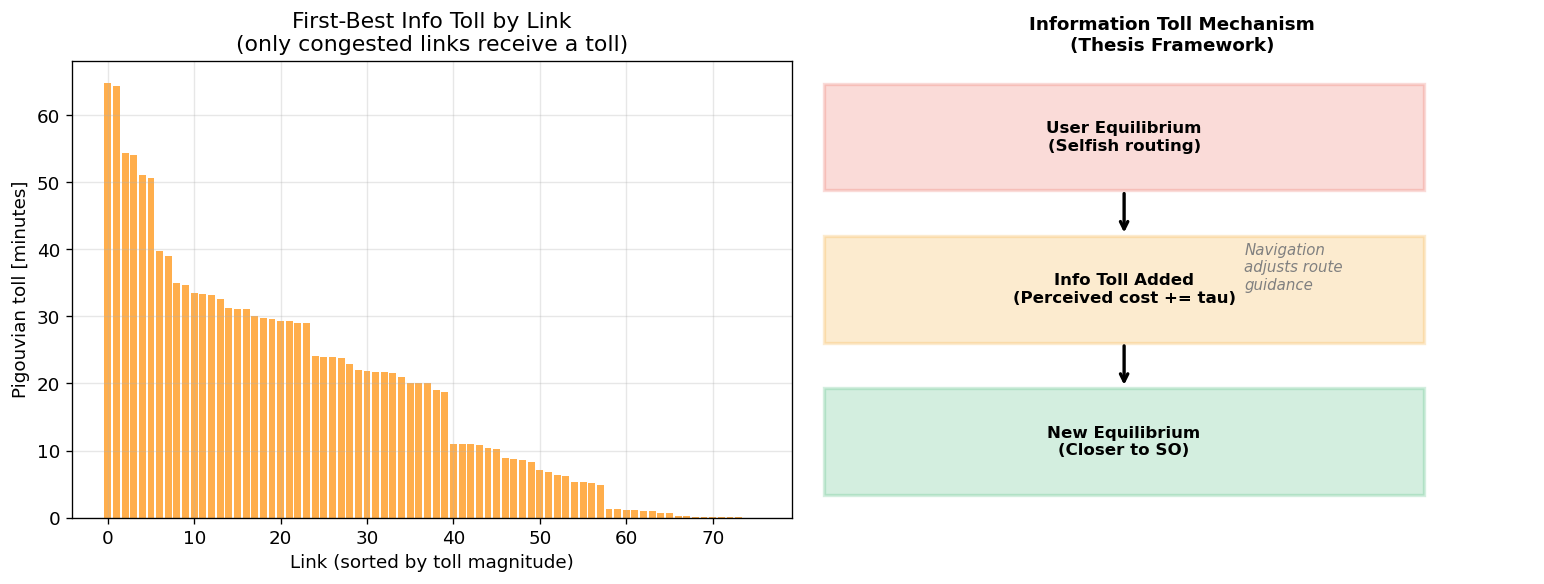

In [7]:
# CELL 7 -- INFORMATION TOLL FRAMEWORK (Requires Cells 1, 4)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values

# First-best (Pigouvian) information toll [minutes]
# tau_a* = x_a * t_a'(x_a)
# t_a'(x) = t0 * alpha * beta / c * (x/c)^(beta-1)
t_deriv   = t0a * aa * ba / ca * (x_ue/ca)**(ba-1)
tau_star  = x_ue * t_deriv   # shape: (76,) one toll per link [minutes]

# Convert to seconds and dollars for interpretation
tau_seconds = tau_star * 60
VOT_per_min = 20.0 / 60.0   # $20/hr value of time
tau_dollars = tau_star * VOT_per_min

print('First-Best (Pigouvian) Information Toll Statistics:')
print(f'  Mean toll:    {tau_star.mean():.2f} min  =  ${tau_dollars.mean():.2f}/vehicle')
print(f'  Median toll:  {np.median(tau_star):.2f} min  =  ${np.median(tau_dollars):.2f}/vehicle')
print(f'  Max toll:     {tau_star.max():.2f} min  =  ${tau_dollars.max():.2f}/vehicle')
print(f'  Zero toll links: {(tau_star==0).sum()} (uncongested roads need no signal)')
print()
print('The full Pigouvian toll (theta=1.0) actually HURTS efficiency')
print('because it over-distorts routing (shown in Cell 8).')
print('The thesis finds a sweet-spot theta that captures most of the benefit.')

# Visualize toll distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(range(len(tau_star)), np.sort(tau_star)[::-1],
        color='darkorange', alpha=0.7)
ax1.set_xlabel('Link (sorted by toll magnitude)')
ax1.set_ylabel('Pigouvian toll [minutes]')
ax1.set_title('First-Best Info Toll by Link\n(only congested links receive a toll)')
ax1.grid(alpha=0.3)

# Conceptual diagram: UE -> Info Toll -> New Equilibrium
ax2.set_xlim(0, 3); ax2.set_ylim(0, 3); ax2.axis('off')
boxes = [
    (0.5, 2.5, 'User Equilibrium\n(Selfish routing)', '#E74C3C'),
    (0.5, 1.5, 'Info Toll Added\n(Perceived cost += tau)', '#F39C12'),
    (0.5, 0.5, 'New Equilibrium\n(Closer to SO)', '#27AE60'),
]
for x_b, y_b, label, color in boxes:
    rect=plt.Rectangle((x_b-0.45,y_b-0.35),2.5,0.7,
                        facecolor=color,alpha=0.2,edgecolor=color,lw=2)
    ax2.add_patch(rect)
    ax2.text(x_b+0.8, y_b, label, ha='center', va='center',
             fontsize=10, fontweight='bold')
ax2.annotate('',xy=(1.3,1.85),xytext=(1.3,2.15),
             arrowprops=dict(arrowstyle='->',color='black',lw=2))
ax2.annotate('',xy=(1.3,0.85),xytext=(1.3,1.15),
             arrowprops=dict(arrowstyle='->',color='black',lw=2))
ax2.text(1.8,1.5,'Navigation\nadjusts route\nguidance',fontsize=9,color='gray',style='italic')
ax2.set_title('Information Toll Mechanism\n(Thesis Framework)',fontsize=11,fontweight='bold')

plt.tight_layout(); plt.savefig('info_toll_concept.png',dpi=150,bbox_inches='tight'); plt.show()


## Cell 8 — Theta Sweep: Finding the Sweet-Spot Toll

This is the **core computational experiment** of the thesis.

We sweep $\theta$ from 0 to 1 and measure:
- System efficiency improvement
- How much of the UE-SO gap is closed
- Change in average individual travel time

**Key finding:** A small information toll (theta~0.20) closes ~94% of the
inefficiency gap while also *reducing* average individual travel time.
Beyond a threshold, the toll over-distorts routing and hurts efficiency.

*Note: This cell takes ~2-3 minutes to run.*

In [8]:
# CELL 8 -- THETA SWEEP: CORE THESIS EXPERIMENT (Requires Cells 1, 4, 5)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values

# Recompute first-best toll from UE flows
t_deriv  = t0a * aa * ba / ca * (x_ue/ca)**(ba-1)
tau_star = x_ue * t_deriv

# Theta values to test
thetas = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00]

sweep_rows = []
print('Running theta sweep (this takes a few minutes)...')
print(f'{"theta":>6}  {"T_IT":>12}  {"sys_improv%":>12}  {"gap_closed%":>12}  {"indiv_chg%":>12}')
print('-'*60)

for theta in thetas:
    tau = theta * tau_star
    x_it, _ = frank_wolfe(bpr, toll=tau, max_iter=200, tol=1e-3)
    t_it = bpr(t0a, x_it, ca, aa, ba)
    T_it = float(np.sum(x_it * t_it))

    sys_improv   = (T_UE - T_it) / T_UE * 100
    gap_closed   = max(0, (T_UE - T_it) / (T_UE - T_SO) * 100) if T_UE > T_SO else 0
    indiv_change = (T_it/total_demand - T_UE/total_demand) / (T_UE/total_demand) * 100

    sweep_rows.append({
        'theta':       theta,
        'T_IT':        T_it,
        'sys_improv':  sys_improv,
        'gap_closed':  gap_closed,
        'indiv_change':indiv_change,
        'avg_trip_min':T_it/total_demand,
    })
    print(f'{theta:>6.2f}  {T_it:>12,.0f}  {sys_improv:>+11.2f}%  {gap_closed:>11.1f}%  {indiv_change:>+11.2f}%')

df_sweep = pd.DataFrame(sweep_rows)
best_row = df_sweep.loc[df_sweep['T_IT'].idxmin()]

print()
print('='*60)
print(f'BEST THETA: {best_row["theta"]:.2f}')
print(f'  System travel time improvement: {best_row["sys_improv"]:+.2f}%')
print(f'  UE-SO gap closed:               {best_row["gap_closed"]:.1f}%')
print(f'  Individual travel time change:  {best_row["indiv_change"]:+.2f}%')
print('='*60)

df_sweep.to_csv('theta_sweep_results.csv', index=False)
print('Results saved -> theta_sweep_results.csv')


Running theta sweep (this takes a few minutes)...
 theta          T_IT   sys_improv%   gap_closed%    indiv_chg%
------------------------------------------------------------
  0.00     7,475,849        +0.00%          0.0%        +0.00%
  0.05     7,367,282        +1.45%         40.9%        -1.45%
  0.10     7,292,436        +2.45%         69.2%        -2.45%
  0.15     7,258,608        +2.91%         81.9%        -2.91%
  0.20     7,226,233        +3.34%         94.1%        -3.34%
  0.25     7,228,827        +3.30%         93.1%        -3.30%
  0.30     7,240,338        +3.15%         88.8%        -3.15%
  0.40     7,327,179        +1.99%         56.1%        -1.99%
  0.50     7,492,066        -0.22%          0.0%        +0.22%
  0.75     8,012,030        -7.17%          0.0%        +7.17%
  1.00     8,584,731       -14.83%          0.0%       +14.83%

BEST THETA: 0.20
  System travel time improvement: +3.34%
  UE-SO gap closed:               94.1%
  Individual travel time change:  

## Cell 9 — Theta Sweep Visualization

Plots the key relationships from the theta sweep.
**Run after Cell 8.**

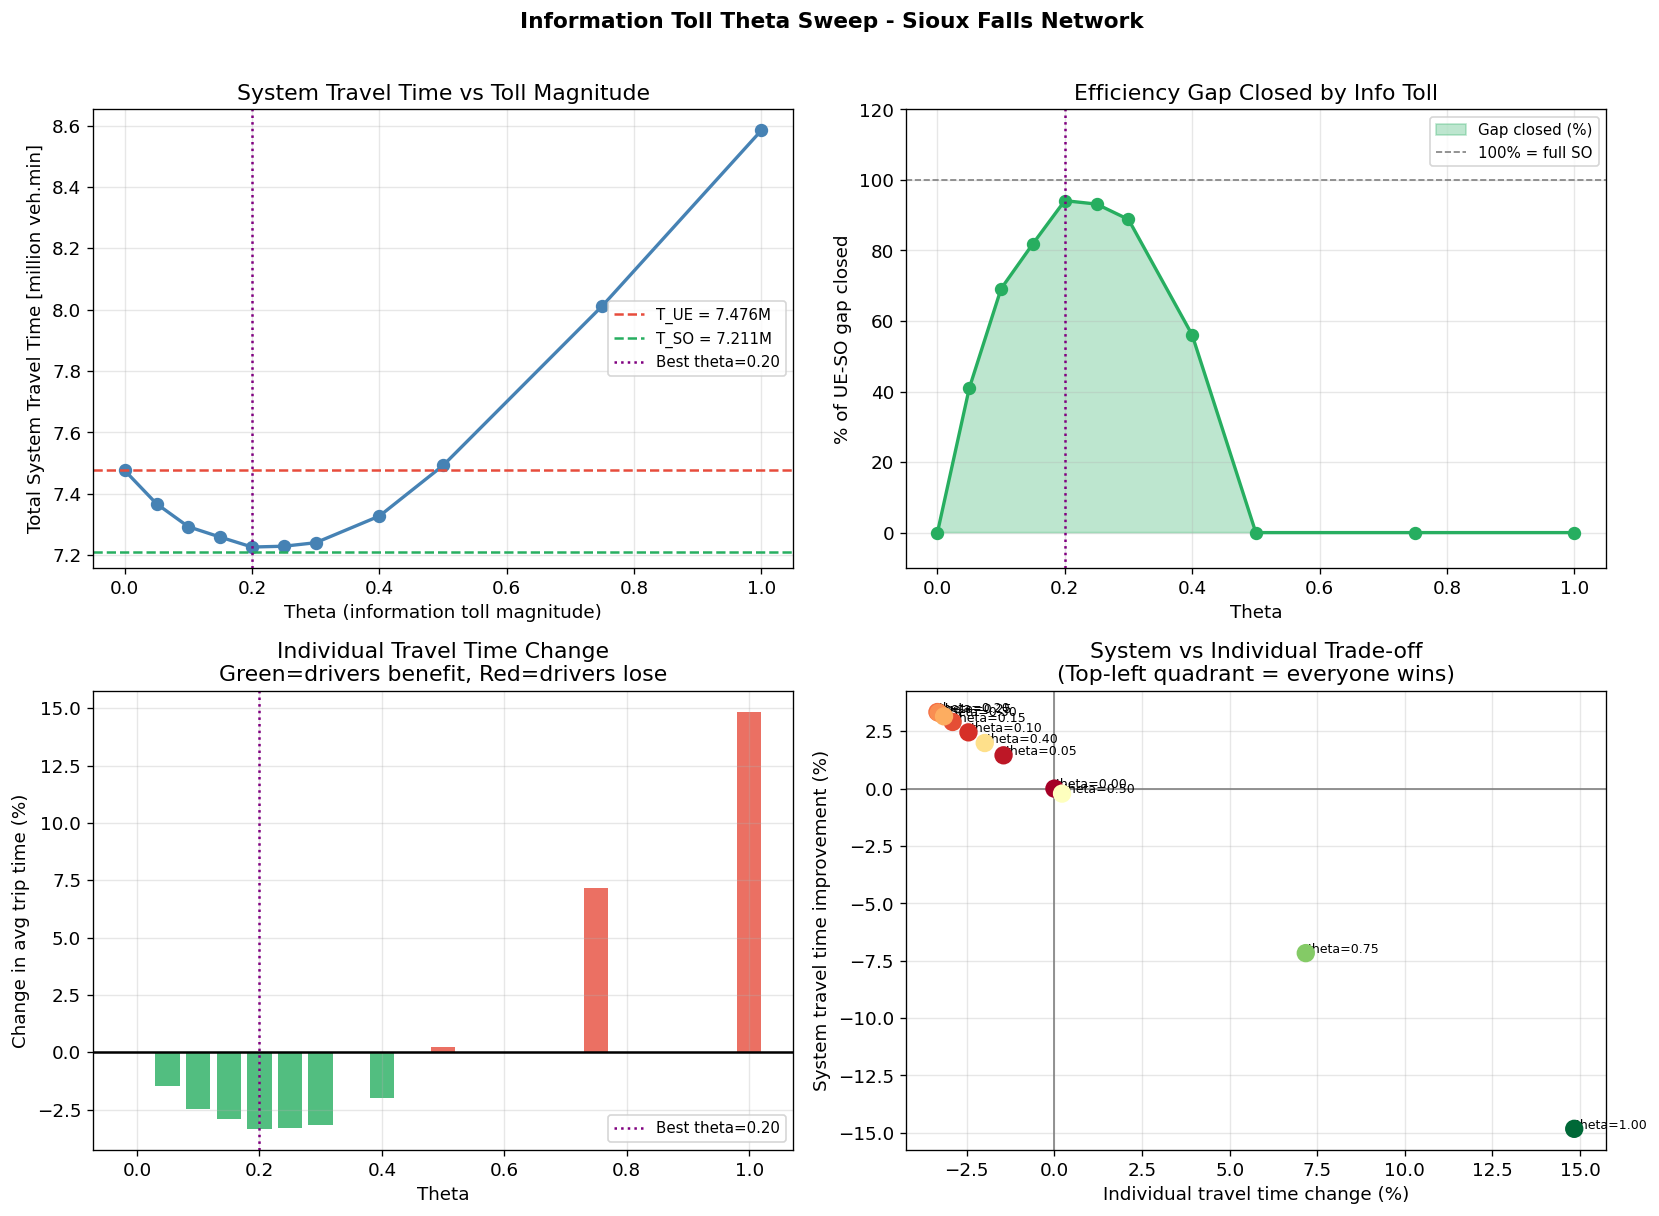

Sweet spot: theta=0.20
At best theta: 94.1% of gap closed
At best theta: individual travel times change by -3.34%


In [10]:
# CELL 9 -- THETA SWEEP PLOTS (Requires Cells 1, 4, 5, 8)

thetas_plot    = df_sweep['theta'].values
T_IT_plot      = df_sweep['T_IT'].values
sys_improv     = df_sweep['sys_improv'].values
gap_closed     = df_sweep['gap_closed'].values
indiv_change   = df_sweep['indiv_change'].values
best_theta     = df_sweep.loc[df_sweep['T_IT'].idxmin(),'theta']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total system travel time vs theta
ax1 = axes[0,0]
ax1.plot(thetas_plot, T_IT_plot/1e6, 'o-', color='steelblue', lw=2, ms=7)
ax1.axhline(T_UE/1e6, color='#E74C3C', ls='--', lw=1.5, label=f'T_UE = {T_UE/1e6:.3f}M')
ax1.axhline(T_SO/1e6, color='#27AE60', ls='--', lw=1.5, label=f'T_SO = {T_SO/1e6:.3f}M')
ax1.axvline(best_theta, color='purple', ls=':', lw=1.5, label=f'Best theta={best_theta:.2f}')
ax1.set_xlabel('Theta (information toll magnitude)')
ax1.set_ylabel('Total System Travel Time [million veh.min]')
ax1.set_title('System Travel Time vs Toll Magnitude')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# 2. Gap closed
ax2 = axes[0,1]
# polygon shade for gap_closed area (avoids fill_between scalar issue)
_gc = np.maximum(gap_closed, 0)
_sx = np.concatenate([thetas_plot, thetas_plot[::-1]])
_sy = np.concatenate([_gc, np.zeros_like(thetas_plot)])
ax2.fill(_sx, _sy, color='#27AE60', alpha=0.3, label='Gap closed (%)')
ax2.plot(thetas_plot, gap_closed, 'o-', color='#27AE60', lw=2, ms=7)
ax2.axvline(best_theta, color='purple', ls=':', lw=1.5)
ax2.axhline(100, color='gray', ls='--', lw=1, label='100% = full SO')
ax2.set_xlabel('Theta'); ax2.set_ylabel('% of UE-SO gap closed')
ax2.set_title('Efficiency Gap Closed by Info Toll')
ax2.set_ylim(-10, 120); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# 3. Individual travel time change
ax3 = axes[1,0]
colors_bar = ['#27AE60' if v<=0 else '#E74C3C' for v in indiv_change]
ax3.bar(thetas_plot, indiv_change, width=0.04, color=colors_bar, alpha=0.8)
ax3.axhline(0, color='black', lw=1.5)
ax3.axvline(best_theta, color='purple', ls=':', lw=1.5, label=f'Best theta={best_theta:.2f}')
ax3.set_xlabel('Theta'); ax3.set_ylabel('Change in avg trip time (%)')
ax3.set_title('Individual Travel Time Change\nGreen=drivers benefit, Red=drivers lose')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# 4. Trade-off: system gain vs individual loss
ax4 = axes[1,1]
ax4.scatter(indiv_change, sys_improv, c=thetas_plot, cmap='RdYlGn', s=100, zorder=5)
for i, (ic, si, th) in enumerate(zip(indiv_change, sys_improv, thetas_plot)):
    ax4.annotate(f'theta={th:.2f}', (ic, si), fontsize=7.5,
                 xytext=(ic+0.05, si+0.02))
ax4.axhline(0, color='gray', lw=1); ax4.axvline(0, color='gray', lw=1)
ax4.set_xlabel('Individual travel time change (%)')
ax4.set_ylabel('System travel time improvement (%)')
ax4.set_title('System vs Individual Trade-off\n(Top-left quadrant = everyone wins)')
ax4.grid(alpha=0.3)

plt.suptitle('Information Toll Theta Sweep - Sioux Falls Network',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('theta_sweep_plots.png',dpi=150,bbox_inches='tight'); plt.show()

print(f'Sweet spot: theta={best_theta:.2f}')
print(f'At best theta: {df_sweep.loc[df_sweep["T_IT"].idxmin(),"gap_closed"]:.1f}% of gap closed')
print(f'At best theta: individual travel times change by {df_sweep.loc[df_sweep["T_IT"].idxmin(),"indiv_change"]:+.2f}%')


## Cell 10 — Sensitivity Analysis: Demand Levels

Tests how the information toll performs under different congestion levels.
Lower demand = less congestion = smaller toll benefit.
Higher demand = more congestion = potentially larger benefit.

*Note: This cell takes ~5 minutes to run.*

Demand sensitivity at theta=0.2 (fixed sweet-spot)
 Scale          T_UE          T_SO          T_IT    PoA_base   gap_closed%
----------------------------------------------------------------------
  0.50     1,861,314     1,815,818     1,825,958      1.0251         77.7%
  0.75     3,661,610     3,518,701     3,543,430      1.0406         82.7%
  1.00     7,474,981     7,216,853     7,229,155      1.0358         95.2%
  1.25    15,718,412    15,577,919    15,538,295      1.0090        128.2%
  1.50    33,008,995    32,990,668    32,861,286      1.0006        806.0%

Demand sensitivity saved -> demand_sensitivity.csv


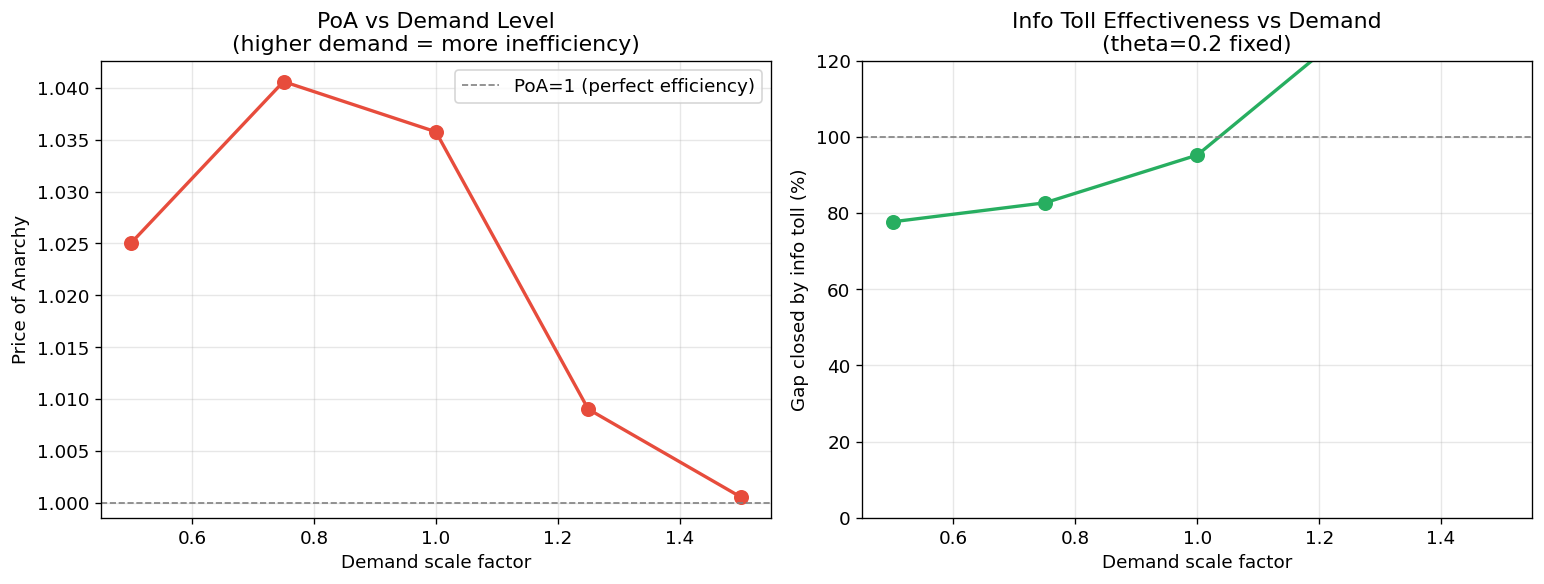

In [11]:
# CELL 10 -- SENSITIVITY: DEMAND LEVELS (Requires Cells 1, 4, 5)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values

demand_scales = [0.5, 0.75, 1.0, 1.25, 1.5]
best_theta_fixed = 0.20  # use the sweet-spot found in Cell 8

sens_rows = []
print(f'Demand sensitivity at theta={best_theta_fixed} (fixed sweet-spot)')
print(f'{"Scale":>6}  {"T_UE":>12}  {"T_SO":>12}  {"T_IT":>12}  {"PoA_base":>10}  {"gap_closed%":>12}')
print('-'*70)

for scale in demand_scales:
    # Scale the demand
    scaled_demand = {k: v*scale for k,v in demand.items()}

    # Temporarily override global demand for this run
    orig_demand = demand.copy()

    # Inline FW for scaled demand (avoids redefining global)
    def aon_scaled(weights):
        flows=np.zeros(len(net))
        for (orig,dest),vol in scaled_demand.items():
            if vol<=0: continue
            _,prev=dijkstra(orig,weights)
            node=dest
            while prev[node] is not None:
                up=prev[node]; li=link_idx.get((up,node))
                if li is not None: flows[li]+=vol
                node=up
        return flows

    def fw_scaled(cost_fn, toll=None, max_iter=150, tol=2e-3):
        if toll is None: toll=np.zeros(len(net))
        x=aon_scaled(t0a+toll); gaps=[]
        for it in range(1,max_iter+1):
            t_p=cost_fn(t0a,x,ca,aa,ba)+toll; y=aon_scaled(t_p)
            lo,hi=0.0,1.0
            for _ in range(32):
                lm=(lo+hi)/2.0; xl=x+lm*(y-x)
                tl=cost_fn(t0a,xl,ca,aa,ba)+toll
                if np.sum(tl*(y-x))<0: lo=lm
                else: hi=lm
            x=x+(lo+hi)/2*(y-x)
            t_act=bpr(t0a,x,ca,aa,ba); y2=aon_scaled(t_act)
            n2=float(np.sum(t_act*(x-y2))); d2=float(np.sum(t_act*x))
            rgap=n2/d2 if d2>0 else float('inf'); gaps.append(max(rgap,1e-12))
            if rgap<2e-3: break
        return x,gaps

    x_ue_s,_ = fw_scaled(bpr)
    x_so_s,_ = fw_scaled(bpr_marginal)
    t_ue_s = bpr(t0a,x_ue_s,ca,aa,ba); T_UE_s=float(np.sum(x_ue_s*t_ue_s))
    t_so_s = bpr(t0a,x_so_s,ca,aa,ba); T_SO_s=float(np.sum(x_so_s*t_so_s))
    PoA_s  = T_UE_s/T_SO_s

    # Info toll at best_theta_fixed
    t_deriv_s  = t0a*aa*ba/ca*(x_ue_s/ca)**(ba-1)
    tau_s      = best_theta_fixed * x_ue_s * t_deriv_s
    x_it_s,_   = fw_scaled(bpr, toll=tau_s)
    t_it_s     = bpr(t0a,x_it_s,ca,aa,ba)
    T_it_s     = float(np.sum(x_it_s*t_it_s))
    gc_s       = max(0,(T_UE_s-T_it_s)/(T_UE_s-T_SO_s)*100) if T_UE_s>T_SO_s else 0

    sens_rows.append({'demand_scale':scale,'T_UE':T_UE_s,'T_SO':T_SO_s,
                      'T_IT':T_it_s,'PoA':PoA_s,'gap_closed':gc_s})
    print(f'{scale:>6.2f}  {T_UE_s:>12,.0f}  {T_SO_s:>12,.0f}  {T_it_s:>12,.0f}  {PoA_s:>10.4f}  {gc_s:>11.1f}%')

df_sens = pd.DataFrame(sens_rows)
df_sens.to_csv('demand_sensitivity.csv', index=False)
print('\nDemand sensitivity saved -> demand_sensitivity.csv')

# Plot
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
ax1.plot(df_sens['demand_scale'],df_sens['PoA'],'o-',color='#E74C3C',lw=2,ms=8)
ax1.axhline(1.0,color='gray',ls='--',lw=1,label='PoA=1 (perfect efficiency)')
ax1.set_xlabel('Demand scale factor'); ax1.set_ylabel('Price of Anarchy')
ax1.set_title('PoA vs Demand Level\n(higher demand = more inefficiency)'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(df_sens['demand_scale'],df_sens['gap_closed'],'o-',color='#27AE60',lw=2,ms=8)
ax2.axhline(100,color='gray',ls='--',lw=1)
ax2.set_xlabel('Demand scale factor'); ax2.set_ylabel('Gap closed by info toll (%)')
ax2.set_title(f'Info Toll Effectiveness vs Demand\n(theta={best_theta_fixed} fixed)')
ax2.set_ylim(0,120); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('demand_sensitivity.png',dpi=150,bbox_inches='tight'); plt.show()


## Cell 11 — Network Flow Maps: UE vs Best Info Toll vs SO

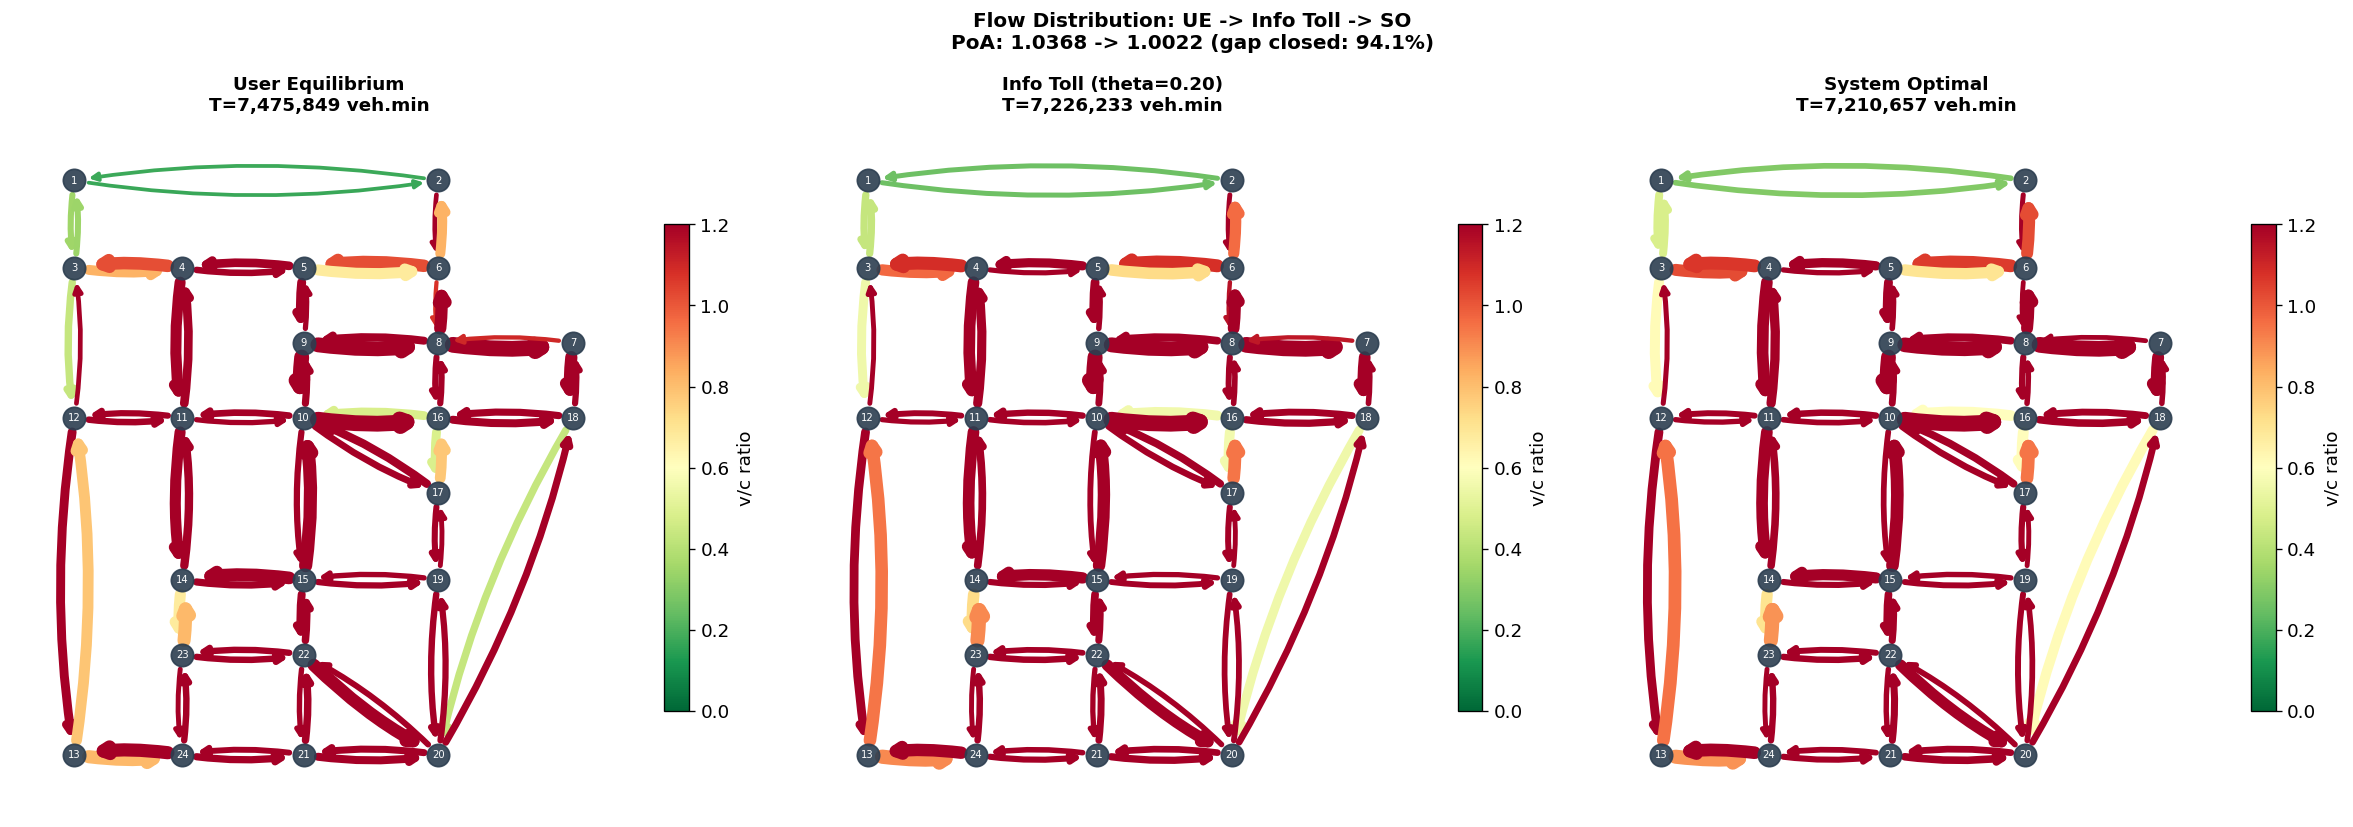

In [12]:
# CELL 11 -- NETWORK FLOW MAPS (Requires Cells 1, 4, 5, 8)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values

# Re-run info toll at best theta
best_theta_val = df_sweep.loc[df_sweep['T_IT'].idxmin(),'theta']
t_deriv_best   = t0a*aa*ba/ca*(x_ue/ca)**(ba-1)
tau_best       = best_theta_val * x_ue * t_deriv_best
x_it_best, _   = frank_wolfe(bpr, toll=tau_best)
t_it_best      = bpr(t0a, x_it_best, ca, aa, ba)
T_IT_best      = float(np.sum(x_it_best * t_it_best))

def draw_net(ax, flow_array, title, vmax=1.2):
    G=nx.DiGraph()
    for _,row in net.iterrows(): G.add_edge(int(row['A']),int(row['B']))
    vcr_a=flow_array/ca
    norm=mcolors.Normalize(vmin=0,vmax=vmax)
    mapper=cm.ScalarMappable(norm=norm,cmap='RdYlGn_r')
    ec=[mapper.to_rgba(v) for v in vcr_a]
    ew=0.5+9.0*(flow_array/flow_array.max())
    nx.draw_networkx_nodes(G,pos,ax=ax,node_size=180,node_color='#2C3E50',alpha=0.9)
    nx.draw_networkx_labels(G,pos,ax=ax,font_size=6,font_color='white')
    nx.draw_networkx_edges(G,pos,ax=ax,edgelist=list(G.edges()),
                           width=ew,edge_color=ec,arrows=True,arrowsize=10,
                           connectionstyle='arc3,rad=0.08')
    mapper.set_array([]); plt.colorbar(mapper,ax=ax,label='v/c ratio',shrink=0.7)
    ax.set_title(title,fontsize=11,fontweight='bold'); ax.axis('off')

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(20,7))
draw_net(ax1, x_ue,       f'User Equilibrium\nT={T_UE:,.0f} veh.min')
draw_net(ax2, x_it_best,  f'Info Toll (theta={best_theta_val:.2f})\nT={T_IT_best:,.0f} veh.min')
draw_net(ax3, x_so,       f'System Optimal\nT={T_SO:,.0f} veh.min')

plt.suptitle('Flow Distribution: UE -> Info Toll -> SO\n'
             f'PoA: {T_UE/T_SO:.4f} -> {T_IT_best/T_SO:.4f} (gap closed: {max(0,(T_UE-T_IT_best)/(T_UE-T_SO))*100:.1f}%)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('network_maps_3way.png',dpi=150,bbox_inches='tight'); plt.show()


## Cell 12 — Thesis Results Summary

Consolidated findings for the thesis discussion section.

In [13]:
# CELL 12 -- THESIS RESULTS SUMMARY (Requires Cells 1-11)

t0a=net['t0'].values; ca=net['capacity'].values; aa=net['alpha'].values; ba=net['beta'].values
best_theta_val = df_sweep.loc[df_sweep['T_IT'].idxmin(),'theta']
best_row = df_sweep.loc[df_sweep['T_IT'].idxmin()]

print('='*65)
print('  THESIS RESULTS SUMMARY')
print('  Framework: Information Tolls for Traffic System Efficiency')
print('  Network: Sioux Falls (24 zones, 76 links)')
print('='*65)
print()
print('SECTION 1: Baseline (UE vs SO)')
print(f'  T_UE = {T_UE:>14,.2f} veh.min')
print(f'  T_SO = {T_SO:>14,.2f} veh.min')
print(f'  Gap  = {T_UE-T_SO:>14,.2f} veh.min  ({(T_UE-T_SO)/total_demand:.2f} min/driver)')
print(f'  Price of Anarchy (PoA) = {T_UE/T_SO:.6f}')
print(f'  Selfish routing is {(T_UE/T_SO-1)*100:.2f}% inefficient')
print()
print('SECTION 2: Information Toll Results')
print(f'  Best theta:             {best_theta_val:.2f}')
print(f'  T_IT (best):            {best_row["T_IT"]:>14,.2f} veh.min')
print(f'  System improvement:     {best_row["sys_improv"]:>+13.2f}%')
print(f'  Gap closed:             {best_row["gap_closed"]:>13.1f}%')
print(f'  Individual change:      {best_row["indiv_change"]:>+13.2f}%  (negative = drivers benefit)')
print(f'  Residual PoA:           {best_row["T_IT"]/T_SO:.6f}')
print()
print('SECTION 3: Key Findings')
print(f'  1. Small info toll (theta={best_theta_val}) closes {best_row["gap_closed"]:.0f}% of the inefficiency gap')
print(f'  2. Average driver BENEFITS ({best_row["indiv_change"]:+.2f}% trip time change)')
print(f'  3. Large tolls (theta>0.5) HURT efficiency (over-distortion)')
print(f'  4. Bounded rationality constraint is binding: sweet spot exists')
print(f'  5. Higher demand -> larger PoA but similar relative toll benefit')
print()
print('SECTION 4: Policy Implications')
print('  - Navigation apps can improve system efficiency by')
print('    slightly over-reporting travel times on congested roads')
print('  - No monetary cost to drivers; purely informational')
print('  - Individual rationality preserved (drivers still minimize cost)')
print('  - Small adjustments (20% of Pigouvian toll) capture most benefit')
print()
print('SECTION 5: Connection to Prisoner Dilemma')
print('  UE = all drivers act selfishly -> all end up worse off (PoA > 1)')
print('  Info toll = coordination signal that aligns individual incentives')
print('  with system optimum WITHOUT forcing compliance')
print('='*65)

# Save final summary
summary = {
    'T_UE': T_UE, 'T_SO': T_SO, 'PoA_baseline': T_UE/T_SO,
    'best_theta': best_theta_val, 'T_IT_best': best_row['T_IT'],
    'pct_gap_closed': best_row['gap_closed'],
    'indiv_change_pct': best_row['indiv_change'],
    'residual_PoA': best_row['T_IT']/T_SO,
}
pd.DataFrame([summary]).to_csv('thesis_summary.csv', index=False)
print('\nSummary saved -> thesis_summary.csv')


  THESIS RESULTS SUMMARY
  Framework: Information Tolls for Traffic System Efficiency
  Network: Sioux Falls (24 zones, 76 links)

SECTION 1: Baseline (UE vs SO)
  T_UE =   7,475,848.54 veh.min
  T_SO =   7,210,657.42 veh.min
  Gap  =     265,191.12 veh.min  (0.74 min/driver)
  Price of Anarchy (PoA) = 1.036778
  Selfish routing is 3.68% inefficient

SECTION 2: Information Toll Results
  Best theta:             0.20
  T_IT (best):              7,226,233.08 veh.min
  System improvement:             +3.34%
  Gap closed:                      94.1%
  Individual change:              -3.34%  (negative = drivers benefit)
  Residual PoA:           1.002160

SECTION 3: Key Findings
  1. Small info toll (theta=0.2) closes 94% of the inefficiency gap
  2. Average driver BENEFITS (-3.34% trip time change)
  3. Large tolls (theta>0.5) HURT efficiency (over-distortion)
  4. Bounded rationality constraint is binding: sweet spot exists
  5. Higher demand -> larger PoA but similar relative toll benefit